In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from minimodel import data, metrics, model_builder, model_trainer

results_path_192 = './results_192-x'
results_path_192_exp = './results_192-x_exp'

output_path = './outputs'

In [24]:
def get_feve_list(results_path):
    feve_mice = []
    for mouse_id in range (6):
        file_name = "results_" + str(mouse_id) + ".npz"
        results_file_path = os.path.join(results_path, file_name)
        data = np.load(results_file_path)
        feve_mouse = data["FEVE_scores"]
        print("feve_mouse: ", feve_mouse.shape, " | ")
        feve_mice.append(feve_mouse)
    feve_mice = np.array(feve_mice)
    return feve_mice

In [13]:
feve_mice = get_feve_list(results_path_192)
feve_mice_exp = get_feve_list(results_path_192_exp)
print(feve_mice)
print()
print(feve_mice_exp)


[[0.56876695 0.6935898  0.71452546 0.7104764 ]
 [0.6443211  0.73315775 0.76437044 0.75973064]
 [0.58689165 0.7208452  0.7474489  0.74623007]
 [0.5690165  0.67543244 0.71330905 0.71740633]
 [0.55430365 0.674633   0.70154774 0.7174395 ]
 [0.6027274  0.7071779  0.73927474 0.7455177 ]]

[[0.51967454 0.65575509 0.68373647 0.68878521]
 [0.53138724 0.65989735 0.69692931 0.69415227]
 [0.52644765 0.64021711 0.68510285 0.69784915]
 [0.53207589 0.66301124 0.69633851 0.68613836]
 [0.53164155 0.65813048 0.66844935 0.69625735]
 [0.52983452 0.6552554  0.67576128 0.68377319]]


In [14]:
def plot_feve_vs_depth(ax, feve_mice, title="FEVE change with model depth"):
    mean = np.mean(feve_mice, axis=0)
    sem = np.std(feve_mice, axis=0, ddof=1) / np.sqrt(feve_mice.shape[0])
    print(f"mean: {mean}")
    print(f"sem: {sem}")

    # plotting mean + SEM
    x = [1,2,3,4]
    for mice_id in range(0,6):
        ax.plot(x, feve_mice[mice_id], color="BLACK", alpha=0.3)

    ax.plot(x, mean, marker="o", markersize= 3, color="BLACK")
    ax.errorbar(x, mean, yerr=sem, capsize=4, color = "BLACK")

    # axis formatting
    ax.set_xlim(0.8,4.2)
    ax.set_xticks([1,2,3,4])
    ax.set_ylim(0.0, 0.8)

    ax.set_ylabel("FEVE")
    ax.set_xlabel("# conv layers")
    ax.set_title(title)

    # top axis with mean values
    ax_top = ax.secondary_xaxis("top")
    ax_top.set_xticks(x)
    ax_top.set_xticklabels([f"{m:.3f}" for m in mean])
    ax_top.set_xlabel("# Mean FEVE")


mean: [0.5876712  0.70080596 0.73007935 0.73280007]
sem: [0.01323539 0.00978046 0.00983083 0.00824342]
mean: [0.52851023 0.65537778 0.6843863  0.69115926]
sem: [0.00195681 0.00324693 0.00458074 0.00234594]


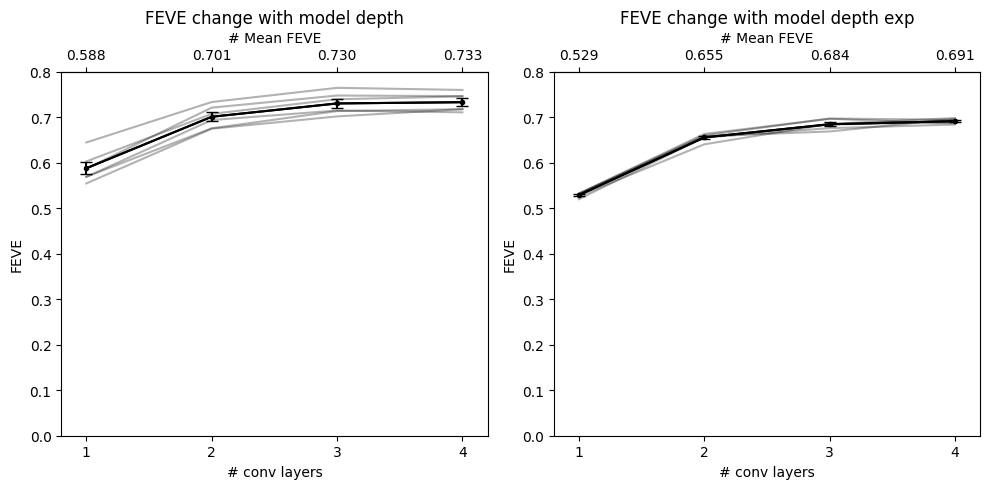

In [ ]:
fig, axis = plt.subplots(1,2, figsize=(10,5))

plot_feve_vs_depth(axis[0], feve_mice)
plot_feve_vs_depth(axis[1], feve_mice_exp, title= "FEVE change with model depth exp")
plt.tight_layout()

output_file_path = os.path.join(output_path, "FEVE_change_with_model_depth_compare")
plt.savefig(output_file_path)

plt.show()

In [27]:
def get_feve_list_2(results_path):
    feve_mice = []
    for mouse_id in range (6):
        file_name = "results_" + str(mouse_id) + ".npz"
        results_file_path = os.path.join(results_path, file_name)
        data = np.load(results_file_path)
        feve_mouse = data["FEVE_scores"]
        fev_mouse = data["FEV_scores"]
        threshold = 0.15
        feve_mouse = np.mean(feve_mouse[fev_mouse > threshold])
        feve_mice.append(feve_mouse)
    feve_mice = np.array(feve_mice)
    return feve_mice

In [32]:
results_path_16_320 = './results_16-320'
results_path_16_320_exp = './results_16-320_exp'
feve_mice = get_feve_list_2(results_path_16_320)
feve_mice_exp = get_feve_list_2(results_path_16_320_exp)
print("feve mice: ", feve_mice)
print("feve mice exp: ",feve_mice_exp)

mean_feve = np.mean(feve_mice)
mean_feve_exp = np.mean(feve_mice_exp)
sem_feve = np.std(feve_mice, axis=0, ddof=1) / np.sqrt(feve_mice.shape[0])
sem_feve_exp = np.std(feve_mice_exp, axis=0, ddof=1) / np.sqrt(feve_mice_exp.shape[0])

feve mice:  [0.6821608  0.7368572  0.7250217  0.6870578  0.67752284 0.7180569 ]
feve mice exp:  [0.6531689  0.63854999 0.66231724 0.66988556 0.66457673 0.64892853]


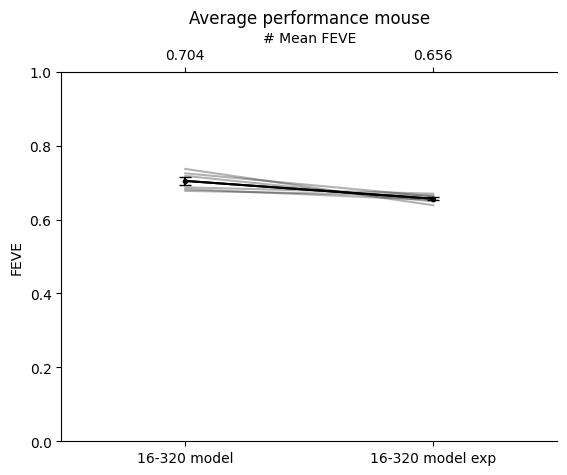

In [34]:
for mice_id in range(0,6):
    y = [feve_mice[mice_id], feve_mice_exp[mice_id]]
    plt.plot(y, color="BLACK", alpha=0.3)

y = [mean_feve, mean_feve_exp]
y_sem = [sem_feve, sem_feve_exp]
plt.plot(y, marker="o", markersize= 3, color="BLACK")
plt.errorbar(
    [0,1],
    y,
    yerr=y_sem,
    capsize=4,
    color = "BLACK"
)


tick_labels = ['16-320 model', '16-320 model exp']
x = [0,1]
plt.xticks(x,tick_labels)
plt.xlim(-0.5, 1.5)
plt.ylim(0.0, 1.0)

# top axis with mean values
ax = plt.gca()
ax_top = ax.secondary_xaxis("top")
ax_top.set_xticks(x)
ax_top.set_xticklabels([f"{m:.3f}" for m in [mean_feve, mean_feve_exp]])
ax_top.set_xlabel("# Mean FEVE")

plt.ylabel("FEVE")
plt.title("Average performance mouse")
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

output_file_path = os.path.join(output_path, "Average_performance_mouse")
plt.savefig(output_file_path)
plt.show()